In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-th4plyqj
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-th4plyqj
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=636f174d68642d11b18ae19982abac5ba094d6bf5b4a50686278b9fc13e9dbee
  Stored in directory: /tmp/pip-ephem-wheel-cache-9xcw7anj/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [20]:
import torch
import clip
from pathlib import Path
import httpx
import os
import skimage
from sklearn.metrics.pairwise import cosine_similarity
import sklearn.metrics
import IPython.display
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from collections import OrderedDict
import torch

In [3]:
print("Available models:", clip.available_models())
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 232MiB/s]


Model parameters: 151,277,313
Input resolution: 224
Context length: 77
Vocab size: 49408


In [4]:
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7d12787d9f80>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

In [5]:
clip.tokenize("a picture of a cat")

tensor([[49406,   320,  1674,   539,   320,  2368, 49407,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], dtype=torch.int32)

In [10]:
import urllib.parse

def getimg(image_url):
    response = httpx.get(image_url)

    parsed_url = urllib.parse.urlparse(image_url)
    query_params = urllib.parse.parse_qs(parsed_url.query)

    if 'dl' in query_params:
        # Use the filename specified in the 'dl' parameter
        image_name = query_params['dl'][0]
    else:
        # Extract filename from the path component of the URL
        image_name = os.path.basename(parsed_url.path)

    # Save the image to disk
    with open(image_name, "wb") as f:
        f.write(response.content)
    print(f"Image downloaded and saved as {image_name}")

getimg("https://live.staticflickr.com/8340/8225434631_95d566b0e3.jpg")
getimg("https://live.staticflickr.com/3013/2828929673_055ba6a9cc_o.jpg")
getimg("https://images.unsplash.com/photo-1602095656818-c66394568279?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=ilse-orsel-dfQPPSApaIY-unsplash.jpg&w=640")
getimg("https://images.unsplash.com/photo-1555719762-671ca39b6fb0?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=kenny-eliason-IF8B82QBCkM-unsplash.jpg&w=640")

Image downloaded and saved as 8225434631_95d566b0e3.jpg
Image downloaded and saved as 2828929673_055ba6a9cc_o.jpg
Image downloaded and saved as ilse-orsel-dfQPPSApaIY-unsplash.jpg
Image downloaded and saved as kenny-eliason-IF8B82QBCkM-unsplash.jpg


In [11]:
list(Path('.').glob('*.jpg'))

[PosixPath('kenny-eliason-IF8B82QBCkM-unsplash.jpg'),
 PosixPath('8225434631_95d566b0e3.jpg'),
 PosixPath('ilse-orsel-dfQPPSApaIY-unsplash.jpg'),
 PosixPath('2828929673_055ba6a9cc_o.jpg')]

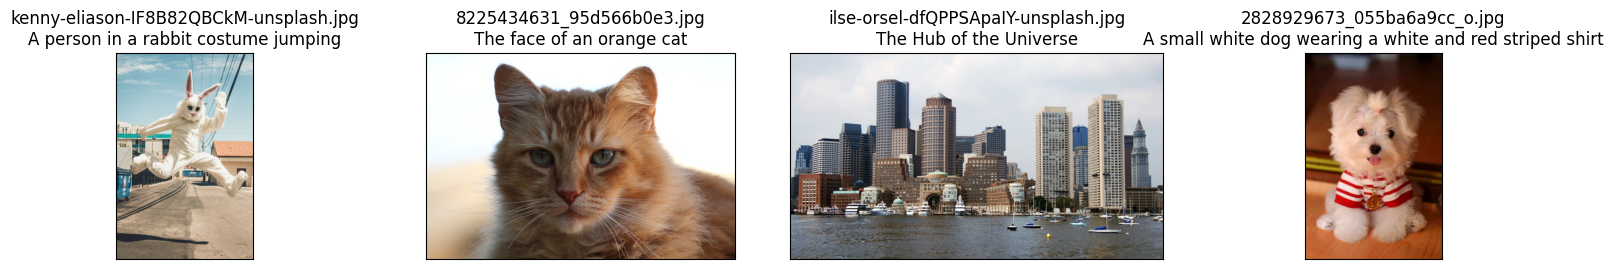

In [12]:
original_images = []
images = []
texts = []
plt.figure(figsize=(16, 5))

descriptions = {
    '8225434631_95d566b0e3': "The face of an orange cat",
    '2828929673_055ba6a9cc_o': "A small white dog wearing a white and red striped shirt",
    'ilse-orsel-dfQPPSApaIY-unsplash': "The Hub of the Universe",
    'kenny-eliason-IF8B82QBCkM-unsplash': 'A person in a rabbit costume jumping',
}

for filename in Path('.').glob('*.jpg'):
    name = filename.stem
    if name not in descriptions:
        continue

    image = Image.open(filename).convert("RGB")

    plt.subplot(2, 4, len(images) + 1)
    plt.imshow(image)
    plt.title(f"{filename}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(image)
    images.append(preprocess(image))
    texts.append(descriptions[name])

plt.tight_layout()


In [13]:
image_input = torch.tensor(np.stack(images)).cuda()
text_tokens = clip.tokenize(["This is " + desc for desc in texts]).cuda()
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = text_features.cpu().numpy() @ image_features.cpu().numpy().T

Text(0.5, 1.0, 'Cosine similarity between text and image features')

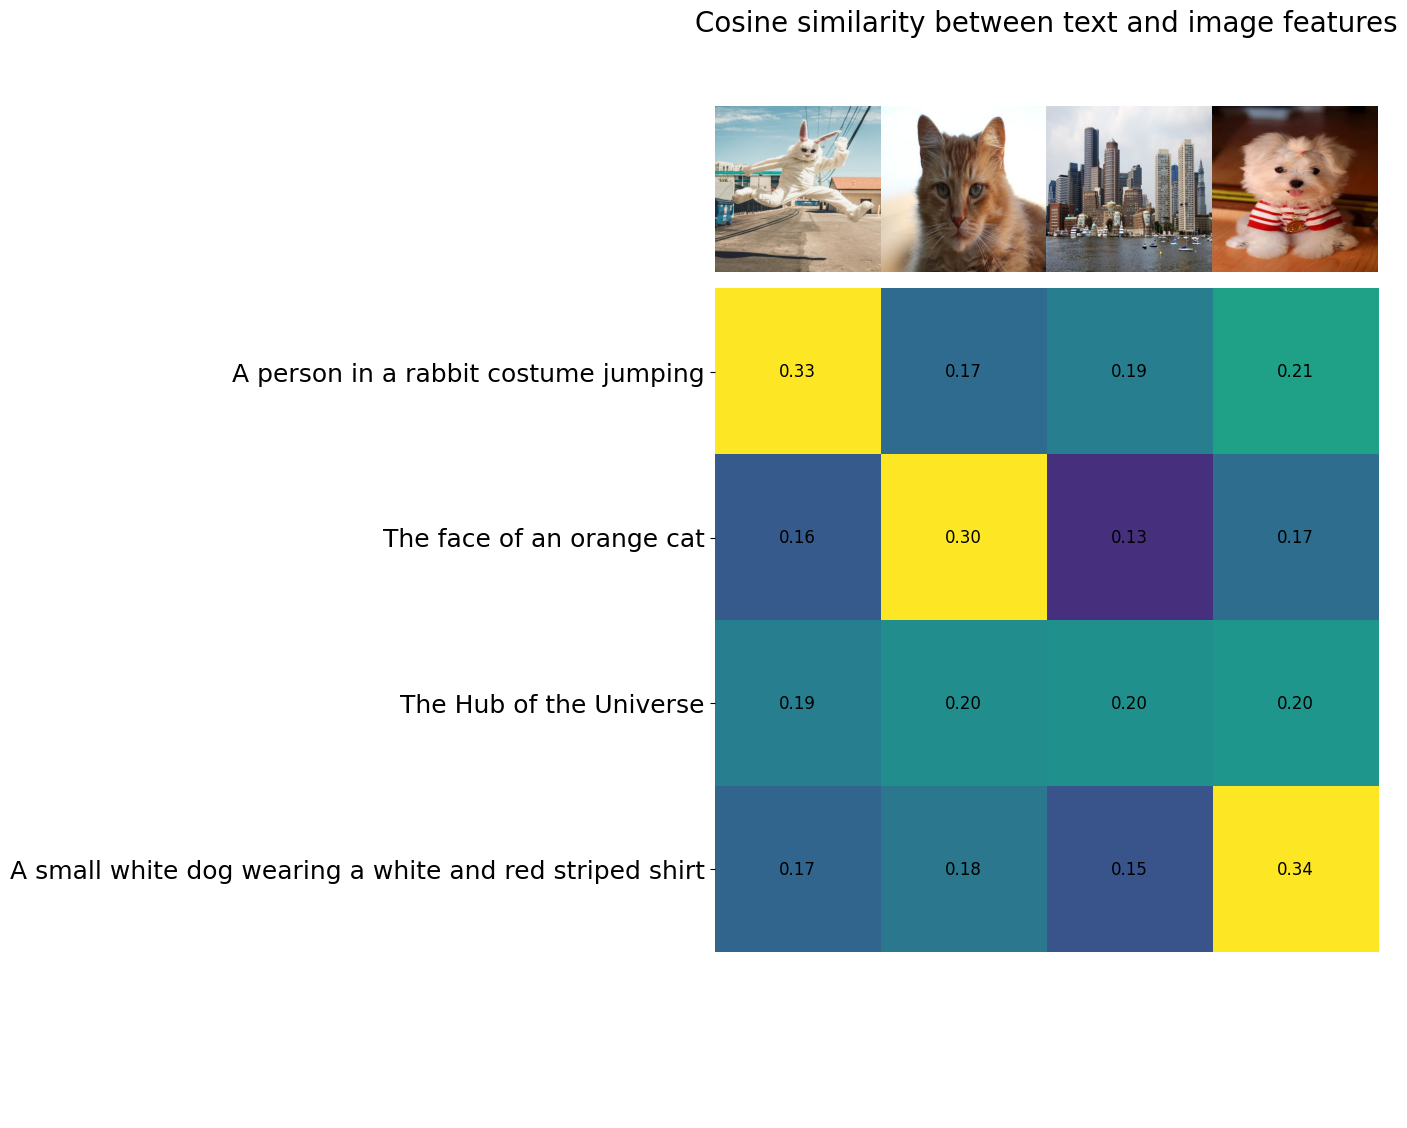

In [14]:
count = len(descriptions)

plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)
# plt.colorbar()
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])
for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)

In [28]:
from torchvision.datasets import CIFAR100

cifar100 = CIFAR100(os.path.expanduser("~/.cache"), transform=preprocess, download=True)
text_descriptions = [f"This is a photo of a {label}" for label in cifar100.classes]
text_tokens = clip.tokenize(text_descriptions).cuda()

In [29]:
with torch.no_grad():
    text_features = model.encode_text(text_tokens).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

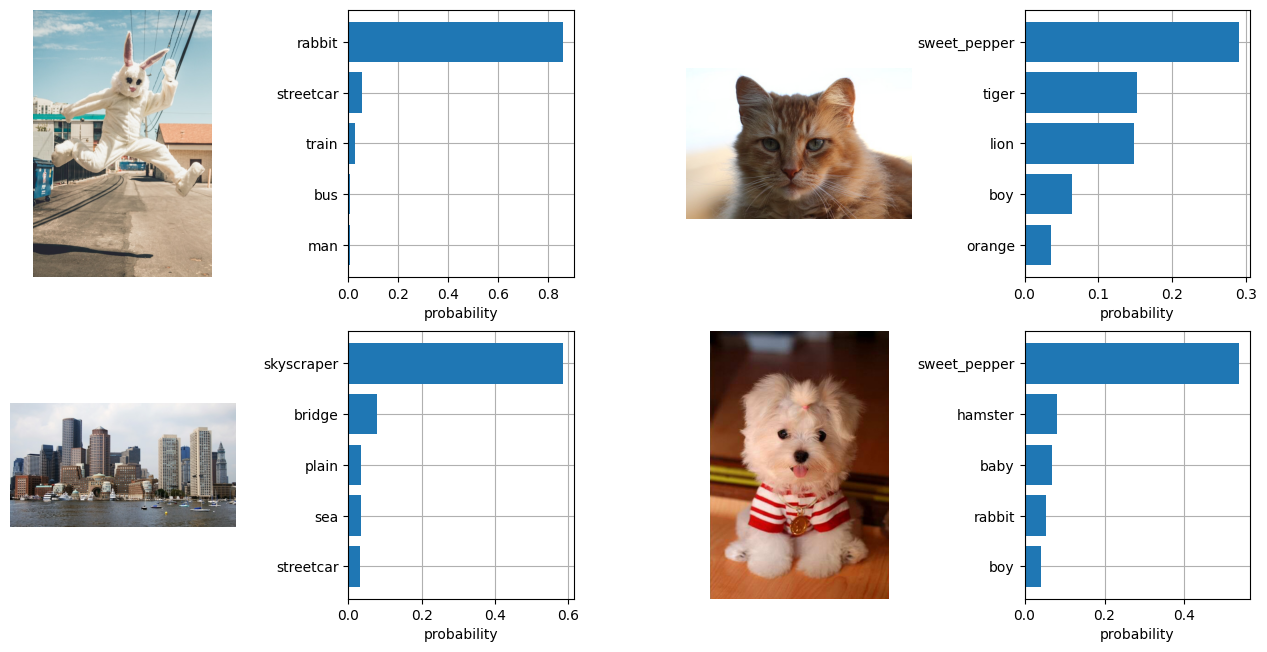

In [30]:
plt.figure(figsize=(16, 16))

for i, image in enumerate(original_images):
    plt.subplot(4, 4, 2 * i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(4, 4, 2 * i + 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs[i])
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [cifar100.classes[index] for index in top_labels[i].numpy()])
    plt.xlabel("probability")

plt.subplots_adjust(wspace=0.5)
plt.show()

`sweet_pepper`?